In [1]:
import sys
sys.path.append(r'../')
import numpy as np
import matplotlib.pyplot as plt


from src.d_CSL import *
from src.dataload import *

# if variables are changed on the fly
from reloading import reloading
from tqdm.notebook import tqdm

No GPU automatically detected. Setting SETTINGS.GPU to 0, and SETTINGS.NJOBS to cpu_count.


In [2]:
%reload_ext autoreload
%autoreload 2
from src.d_CSL import *

## Simulate data

An example ground truth connectivity matrix `A`

In [3]:
np.random.seed(3465)
n_neur=30
A = np.random.choice([0,0.5,0.85], p=[0.9,0.03,0.07], size=(n_neur,n_neur)) ### A is not the adjacency matrix in the typical sense
A = 0.5*(A)
A[0:10,0:10] =np.zeros((10,10))
for n, i in enumerate(A):
    A[n][n]=1
for n, i in enumerate(A):
    A[n]=A[n]/np.sum(A[n])
A.shape

(30, 30)

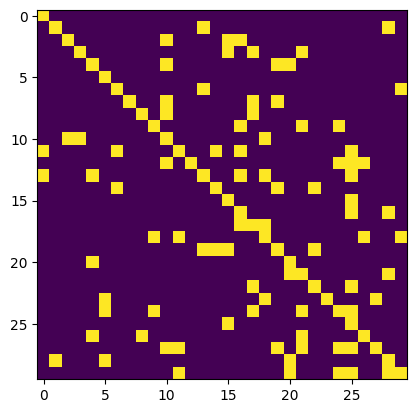

In [4]:
np.random.seed(111)
mask = np.random.random((A.shape[0],A.shape[1]))>0.55
np.fill_diagonal(mask,1)
B_ = np.multiply(A,1-mask)
A_ = np.multiply(A,mask)
A = np.logical_or(A_, B_)
plt.imshow(A)

In [5]:
def continuous_noise_fun(num, l=5000):
    xx = np.linspace(0,500,l)
    noise = np.zeros((num,l))
    for i in range(num):
        a = 2*np.random.normal(0,0.25,size=6)
        c = 500*(np.random.random(size=6))
        s = 1+100*(np.random.random(size=6))
        yy = 0*xx
        for j in range(6):
            yy = yy + a[j]*np.exp(-(xx-c[j])**2/s[j])
        noise[i] = yy
    return noise
np.random.seed(13)

noise = continuous_noise_fun(num=n_neur, l=5000)

In [6]:
noise.shape

(30, 5000)

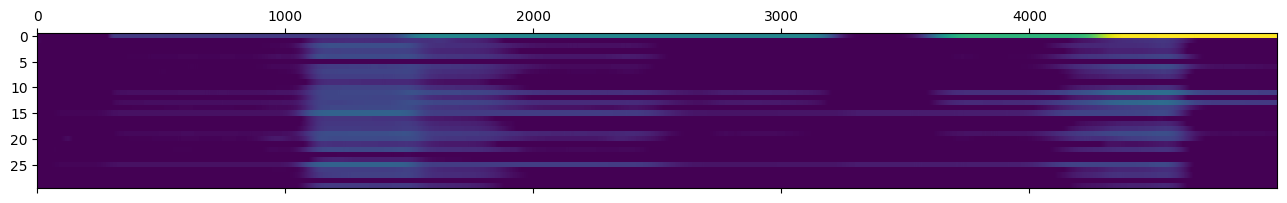

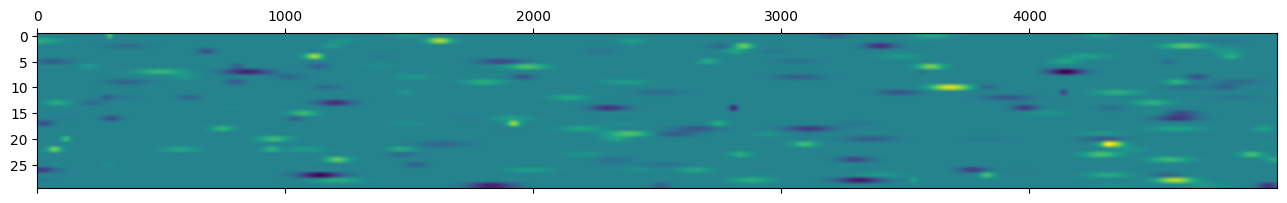

In [7]:
X = np.zeros([A.shape[0],5000]).T
X[0] = np.random.randn(A.shape[0])
for i, row in enumerate(X[:-1]):
    X[i+1] = A_ @ X[i] + B_ @ X[i-1] + 0.05*np.random.normal(0,0.25,A.shape[0]) + noise[:,i]
X=X.T
plt.matshow(X, aspect='auto',vmin=0)
plt.matshow(noise, aspect='auto', interpolation=None)

In [8]:
# X = np.load(r"data/SimData2Lags.npy")

## Analysis

In [9]:
N_PASTS, n_lags, n_perm = np.arange(1, 8, 1), 2, 1000
alpha, beta = 0.01, 0.001

In [10]:
infs_fgc = []
conf_mtx_fgc = []
shds_fgc = []
metrics_fgc = []
# for i, n in enumerate(N_PASTS):
for i in range(2):
    print(f'{i}')
    gcstar = GcStar(n_perm = 1000,
                    n_pasts = 3,
                    n_lags = n_lags,
                    temporal = True,
                    method = 'cgc')

    gcstar.fit(X, verbose = 0)
    inf = gcstar.get_connectivity_matrix(alpha=alpha, beta=beta, simulation=True)
    infs_fgc.append(inf)
    conf_mtx_fgc.append(gcstar.compute_confusion_matrix(A, simulation=True))
    metrics_fgc.append(np.round(gcstar.all_metrics(), 4))
    shds_fgc.append(np.round(gcstar.compute_shd_sid(A, inf, simulation=True), 4))

0
1


In [11]:
print(shds_fgc)
np.round(metrics_fgc, 4)

[np.float64(61.7008), np.float64(62.2019)]


array([[0.9244, 0.6391, 0.9391, 0.0777, 0.9307, 0.7606],
       [0.9244, 0.6407, 0.9304, 0.0764, 0.927 , 0.7589]])

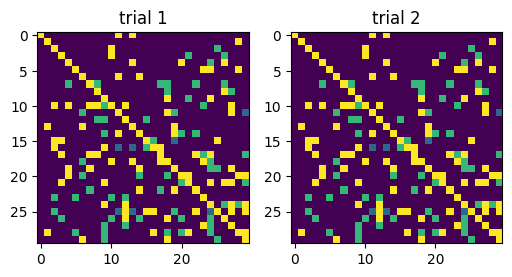

In [12]:
fig, axes = plt.subplots(1,len(infs_fgc), figsize=(3*len(infs_fgc), 4))
for i, ax in enumerate(axes):
    ax.imshow(compare_with_GT(A, infs_fgc[0], simulation=True))
    ax.set_title(f'trial {i+1}')

In [13]:
stop

NameError: name 'stop' is not defined

labels = ['Acc', 'Prec', 'Rec', 'FPR']
fig, ax = plt.subplots(1, 4, figsize=(12, 3))
for i in range(metrics.shape[1]):
    ax[i].plot(metrics[:, i], marker = '.', label = labels[i], c = 'blue')
    ax[i].set_xticks(np.arange(metrics.shape[0]), list(np.arange(1, 8, 1)))
    ax[i].set_xlabel('$n_{pasts}$')
    ax[i].set_ylabel('%', rotation = 180)
    ax[i].set_title(f'{labels[i]}')
plt.tight_layout()

def mat_func(A,inf):
    return 40*np.logical_and(A!=0,inf!=0) + 30*np.logical_and(A==0,inf!=0) + 20*np.logical_and(A!=0,inf==0)+10*np.logical_and(A==0,inf==0)

for i, el in enumerate(infs):
    plt.figure(figsize = (5,5))
    plt.imshow(mat_func(A.T, el))
    plt.title(f'{i+1} pasts')

def confusion_matrix(inferred, A):
    TP_inf = np.sum(np.logical_and(A != 0,inferred!=0))
    FN_inf = np.sum(np.logical_and(A != 0,inferred==0))
    FP_inf = np.sum(np.logical_and(A == 0,inferred!=0))
    TN_inf = np.sum(np.logical_and(A == 0,inferred==0))
    return np.array([[TP_inf,FN_inf],
                     [FP_inf,TN_inf]])